In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, make_scorer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
#Data set
df = pd.read_csv('CpyAllVars.csv')
#Encoding the outcome: 1 = Pre-Diabetic, 0 = Normal according to HbA1c levels
df['PreDiabetes'] = df['HS_HbA1c'].apply(lambda x: 0 if x < 5.7 else (1 if 5.7 <= x <= 6.4 else np.nan)) #assigns np.nan to values outside the expected range
df.dropna(subset=['PreDiabetes'], inplace=True) #Drop diabetes patients
df.dropna(subset=['Age', 'HS_WHRatio', 'HS_BMI','IL.1b', 'IL.6', 'TNF.a', 'IFN.g', 'MCP.1'], inplace=True) 
X = df[['Age', 'HS_WHRatio', 'HS_BMI', 'IL.1b', 'IL.6','TNF.a', 'IFN.g', 'MCP.1']]  
y = df['PreDiabetes']

In [ ]:
#Summary for X
summary_cont = X.describe().T

#Add median
summary_cont["median"] = X.median()

#Reorder columns
summary_cont = summary_cont[["count", "mean", "std", "median", "min", "max"]]

print("\nSummary statistics for cytokines and anthropometrics:\n")
print(summary_cont)

#Summary for y
summary_target = y.value_counts().to_frame()
summary_target.columns = ["Count"]
summary_target["Percentage (%)"] = 100 * summary_target["Count"] / len(df)

print("\nPreDiabetes class distribution:\n")
print(summary_target)

#Combine
summary_table = summary_cont.copy()
summary_table.loc["PreDiabetes (Yes=1)"] = ["-", "-", "-", "-", "-", "-"]

print("\nCombined summary table:\n")
print(summary_table)



Summary statistics for cytokines and anthropometrics:

            count        mean        std    median    min     max
Age         156.0   45.115385  15.012237   45.5000  18.00   77.00
HS_WHRatio  156.0    0.874733   0.099980    0.8645   0.67    1.44
HS_BMI      156.0   30.224744   7.379244   28.8000  16.00   61.30
IL.1b       156.0   10.489359  11.396327    7.1650   1.16  100.15
IL.6        156.0    2.684679   2.602323    2.0600   0.02   15.80
TNF.a       156.0   32.301923  65.378576   21.2600   4.54  731.44
IFN.g       156.0   39.942500  68.171169   21.2450   1.04  515.93
MCP.1       156.0  236.836154  68.205515  229.0300  47.84  482.46

PreDiabetes class distribution:

             Count  Percentage (%)
PreDiabetes                       
0.0            107       68.589744
1.0             49       31.410256

Combined summary table:

                     count        mean        std  median    min     max
Age                  156.0   45.115385  15.012237    45.5   18.0    77.0
HS_W

In [6]:
summary_pub = pd.DataFrame({
    "Mean ± SD": X.apply(
        lambda x: f"{x.mean():.2f} ± {x.std():.2f}"
    ),
    "Min–Max": X.apply(
        lambda x: f"{x.min():.2f}–{x.max():.2f}"
    )
})

print("\nSummary table:\n")
print(summary_pub)



Summary table:

                 Mean ± SD       Min–Max
Age          45.12 ± 15.01   18.00–77.00
HS_WHRatio     0.87 ± 0.10     0.67–1.44
HS_BMI        30.22 ± 7.38   16.00–61.30
IL.1b        10.49 ± 11.40   1.16–100.15
IL.6           2.68 ± 2.60    0.02–15.80
TNF.a        32.30 ± 65.38   4.54–731.44
IFN.g        39.94 ± 68.17   1.04–515.93
MCP.1       236.84 ± 68.21  47.84–482.46


In [3]:
selected_features = ['Age', 'TNF.a', 'MCP.1', 'HS_BMI', 'HS_WHRatio']
X_reduced = X[selected_features]

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),  # scale for LR
        ('lr', LogisticRegression(
            class_weight='balanced',
            random_state=0,
            max_iter=1000
        ))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight='balanced',
        random_state=0
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=0,
        n_jobs=-1
    ),
    
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),  # k-NN requires scaling
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
}


In [5]:
#Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

results = {}

for name, model in models.items():
    # Use scoring='roc_auc' directly
    auc_scores = cross_val_score(model, X_reduced, y, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X_reduced, y, cv=cv, scoring='accuracy')
    results[name] = {
        'Mean AUC': auc_scores.mean(),
        'Std AUC': auc_scores.std(),
        'Mean Accuracy': acc_scores.mean(),
        'Std Accuracy': acc_scores.std()
    }

df_results = pd.DataFrame(results).T
print("\nCross-validated model performance:\n")
print(df_results)


Cross-validated model performance:

                     Mean AUC   Std AUC  Mean Accuracy  Std Accuracy
Logistic Regression  0.712684  0.042562       0.640524      0.064678
Decision Tree        0.671797  0.050845       0.615323      0.070839
Random Forest        0.767677  0.022824       0.686089      0.035541
k-NN                 0.746659  0.052908       0.698992      0.041297


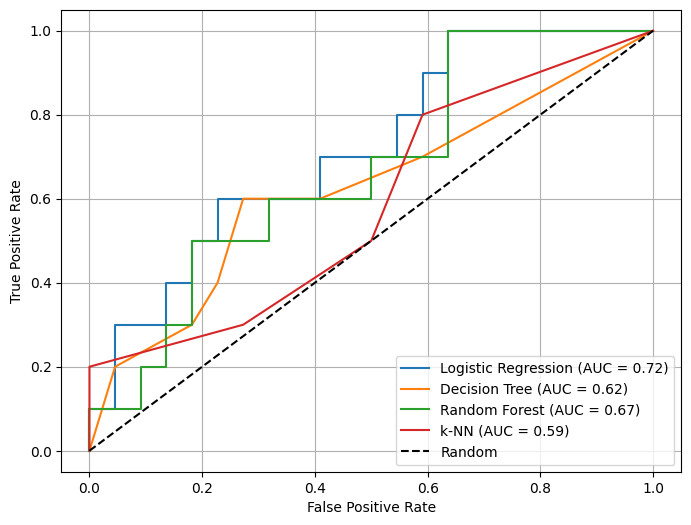

In [7]:
#ROC visualization
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=0
)

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:  # some models may use decision_function
        proba = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curves for Disease Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("AUC.pdf", bbox_inches="tight")
plt.show()

In [8]:
#Base logistic regression
print("\nFitting baseline Logistic Regression on entire dataset...")
base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
base_model.fit(X_reduced, y)


Fitting baseline Logistic Regression on entire dataset...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)

In [9]:
# Feature importance for logistic regression (coefficients)
coef = pd.Series(base_model.coef_[0], index=X_reduced.columns).sort_values(key=abs, ascending=False)
print("\nLogistic Regression feature importance (absolute value of coefficients):\n")
print(coef)


Logistic Regression feature importance (absolute value of coefficients):

HS_WHRatio    0.526646
HS_BMI        0.059308
Age           0.056734
MCP.1         0.005348
TNF.a        -0.004237
dtype: float64


In [10]:
#Feature importance for tree-based models

for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=X_reduced.columns).sort_values(ascending=False)
        print(f"\n{name} feature importance:\n{imp}")


Decision Tree feature importance:
Age           0.511063
TNF.a         0.226516
MCP.1         0.169283
HS_WHRatio    0.048974
HS_BMI        0.044164
dtype: float64

Random Forest feature importance:
Age           0.319445
MCP.1         0.247567
HS_WHRatio    0.208449
TNF.a         0.134784
HS_BMI        0.089755
dtype: float64


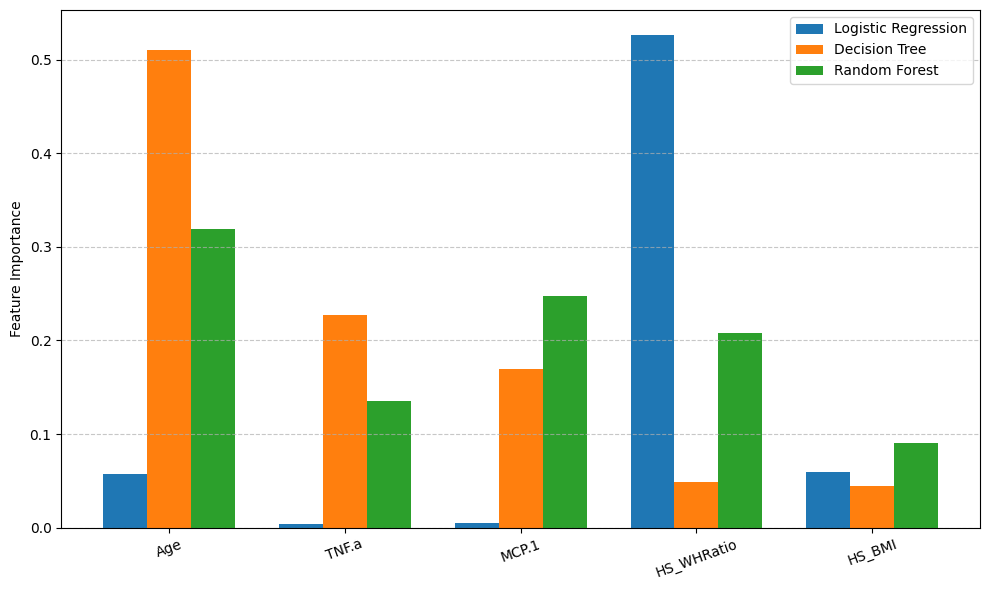

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ----------------------------
# 1. Feature importance data
# ----------------------------

features = ['Age', 'TNF.a', 'MCP.1', 'HS_WHRatio', 'HS_BMI']

# Feature importance values you provided
lr_importance = [0.057, 0.004, 0.005, 0.527, 0.059]
dt_importance = [0.511, 0.227, 0.169, 0.049, 0.044]
rf_importance = [0.319, 0.135, 0.248, 0.208, 0.090]

# Combine into DataFrame for easier plotting
df_imp = pd.DataFrame({
    'Logistic Regression': lr_importance,
    'Decision Tree': dt_importance,
    'Random Forest': rf_importance
}, index=features)

# ----------------------------
# 2. Plotting
# ----------------------------

# Set up bar positions
x = np.arange(len(features))  # label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))

# Plot each model's bars
ax.bar(x - width, df_imp['Logistic Regression'], width, label='Logistic Regression', color='#1f77b4')
ax.bar(x, df_imp['Decision Tree'], width, label='Decision Tree', color='#ff7f0e')
ax.bar(x + width, df_imp['Random Forest'], width, label='Random Forest', color='#2ca02c')

# Labels and titles
ax.set_ylabel('Feature Importance')
#ax.set_title('Feature Importance Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: rotate x labels if needed
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("feat-importance.pdf", bbox_inches="tight")
plt.show()
